In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("spam_ham_dataset.csv")

In [4]:
df.sample(5)

,Unnamed: 0,label,text,label_num
4716,3115,ham,Subject: txu fuels / sds nomination for may 20...,0
2717,4748,spam,Subject: date a new wild babe tonight\r\nbored...,1
2919,1076,ham,Subject: unfinaled sales invoices\r\nhere are ...,0
4840,4941,spam,Subject: your investor communiqup 9\r\nget abz...,1
4023,2856,ham,Subject: re : cp & l\r\ncan we verified this g...,0


In [5]:
df.shape

(5171, 4)

## Data cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


In [7]:
# drop unnamed column
df.drop(columns=['Unnamed: 0'],inplace=True)

In [8]:
df.sample(5)

,label,text,label_num
752,ham,Subject: tenaska iv 11 / 01\r\ndarren :\r\nit ...,0
2079,ham,Subject: sitara position\r\nplease use the pos...,0
4506,spam,Subject: hii . . !\r\nnow online with profiles...,1
35,spam,Subject: end of year clearance\r\nitem no #\r\...,1
2454,ham,Subject: re : coastal ctr # 96008903 meter 098...,0


In [9]:
# renaming the columns
df.rename(columns={'label':'Type','label_num':'Type_no'},inplace=True)
df.sample()

,Type,text,Type_no
4672,spam,"Subject: play on ocean treasure casino , get $...",1


In [10]:
# their is no need for label encoder but if was required
# form sklearn.preprocessing import LabelEncoder
#encoder=LabelEncoder()
#df['type']=encoder.fit_trasnform(df['type'])

In [11]:
# missing values
df.isnull().sum()

,0
Type,0
text,0
Type_no,0


In [12]:
#check for duplicate values
df.duplicated().sum()

np.int64(178)

In [13]:
df = df.drop_duplicates(keep='first')

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(4993, 3)

## EDA

In [16]:
df['Type_no'].value_counts()

,count
Type_no,
0,3531
1,1462


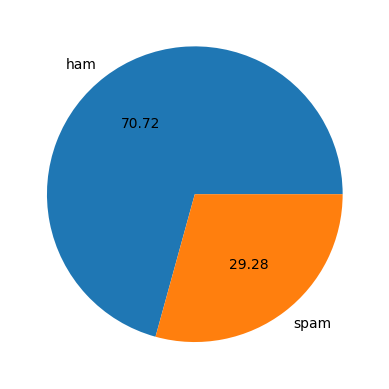

In [17]:
import matplotlib.pyplot as plt
plt.pie(df['Type_no'].value_counts(), labels=['ham','spam'], autopct= "%0.2f")
plt.show()

In [18]:
# data is imbalanced

In [19]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
# characters in mail
df['num_characters']=df['text'].apply(len)
df.head()

,Type,text,Type_no,num_characters
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0,327
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524
3,spam,"Subject: photoshop , windows , office . cheap ...",1,414
4,ham,Subject: re : indian springs\r\nthis deal is t...,0,336


In [21]:
# words in mail
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [22]:
# sentence in mail
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [23]:
df.head()

,Type,text,Type_no,num_characters,num_words,num_sentences
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0,327,68,3
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97,24,3
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524,551,24
3,spam,"Subject: photoshop , windows , office . cheap ...",1,414,49,3
4,ham,Subject: re : indian springs\r\nthis deal is t...,0,336,71,3


In [24]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4993.000000,4993.000000,4993.000000
mean,1069.426397,233.678149,13.386942
std,1547.863387,340.702932,27.959959
min,11.000000,2.000000,1.000000
25%,256.000000,55.000000,4.000000
50%,557.000000,125.000000,7.000000
75%,1262.000000,288.000000,15.000000
max,32258.000000,8863.000000,1204.000000


In [25]:
# ham
df[df['Type_no'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,3531.000000,3531.000000,3531.000000
mean,994.939394,230.516001,11.662419
std,1402.785831,337.018933,25.330035
min,18.000000,3.000000,1.000000
25%,241.000000,53.000000,4.000000
50%,538.000000,128.000000,7.000000
75%,1253.500000,298.500000,13.500000
max,32258.000000,8863.000000,1204.000000


In [26]:
# spam
df[df['Type_no'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,1462.000000,1462.000000,1462.000000
mean,1249.326265,241.315321,17.551984
std,1840.112883,349.439381,33.111447
min,11.000000,2.000000,1.000000
25%,304.250000,60.000000,4.000000
50%,589.000000,119.500000,9.000000
75%,1305.000000,252.750000,19.000000
max,22073.000000,3963.000000,693.000000


<Axes: xlabel='num_characters', ylabel='Count'>

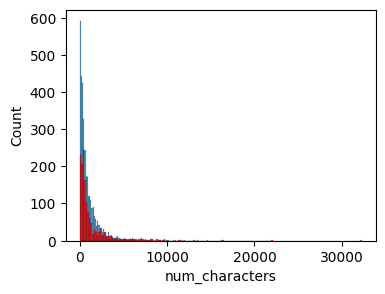

In [27]:
import seaborn as sns
plt.figure(figsize=(4,3))
sns.histplot(df[df['Type_no']==0]['num_characters'])
sns.histplot(df[df['Type_no']==1]['num_characters'],color = 'red')

<Axes: xlabel='num_words', ylabel='Count'>

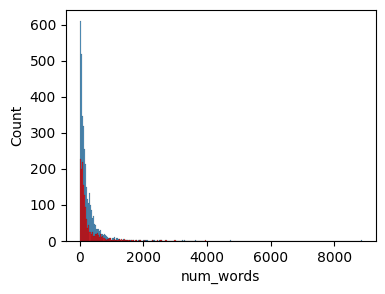

In [28]:
plt.figure(figsize=(4,3))
sns.histplot(df[df['Type_no']==0]['num_words'])
sns.histplot(df[df['Type_no']==1]['num_words'],color = 'red')

<Figure size 400x300 with 0 Axes>

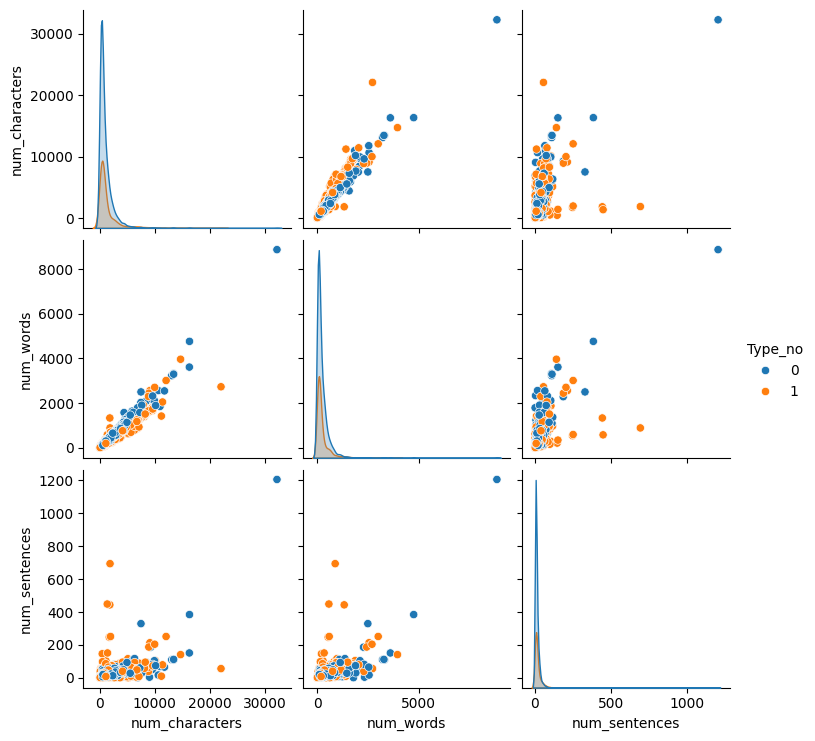

In [29]:
plt.figure(figsize=(4,3))
sns.pairplot(df,hue='Type_no')

<Axes: >

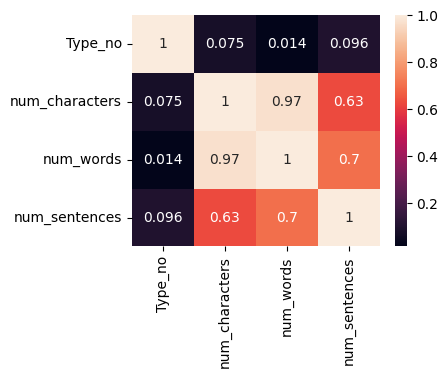

In [30]:
plt.figure(figsize=(4,3))
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Data Preprocessing
* lower case
* tokenization
* removing special character
* removing stop word
* stemming/lemitization


In [31]:
import string
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [32]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()# y need to be cloned else if y cleared then text also get cleared

    # List of common words to remove that do not affect prediction
    common_words_to_remove = ['subject']

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation and i not in common_words_to_remove:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [33]:
df['transformed_text'] = df['text'].apply(transform_text)

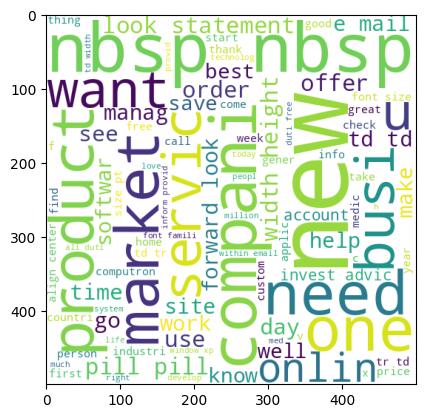

In [34]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')
spam_wc = wc.generate(df[df['Type_no'] == 1]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

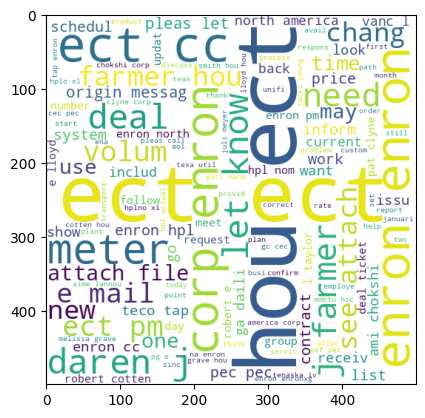

In [35]:
ham_wc = wc.generate(df[df['Type_no'] == 0]['transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)

In [36]:
#first with naive basse since it perform well on text data
#text into words= bag of words(frequent word columns),tfidf,word to vector


## Model building

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer #,CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
#cv = CountVectorizer() #CountVectorizer=bag of word


In [38]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['transformed_text']).toarray()
X.shape

(4993, 42592)

In [39]:
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# X = scaler.fit_transform(X)

# appending the num_character col to x
# X = np.hstack((X,df['num_words'].values.reshape(-1,1)))

In [40]:
y = df['Type_no'].values

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import (
    MultinomialNB,
    BernoulliNB,
    GaussianNB
)
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier

In [43]:
svc = SVC(kernel ='sigmoid', gamma=1.0)
# knc = KNeighborsClassifier()
mnb = MultinomialNB()
# bnb = BernoulliNB()
gnb = GaussianNB()
# dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver = 'liblinear', penalty ='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state = 2)
# abc = AdaBoostClassifier(n_estimators=50, random_state = 2)
bc = BaggingClassifier(n_estimators=50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators=50, random_state = 2)
gbc = GradientBoostingClassifier(n_estimators=50, random_state = 2)
xgb = XGBClassifier(n_estimators=50, random_state = 2)
#basic hyperparameter tunning

In [44]:
clfs = {
    'SVC' : svc,
    # 'KN' : knc,
    'MNB' : mnb,
    # 'BNB' : bnb,
    'GNB' : gnb,
    # 'DT' : dtc,
    'LR' : lrc,
    'RF' : rfc,
    # 'AdaBoost' : abc,
    'Bgc' : bc,
    'ETC' : etc,
    'GBDT' : gbc,
    'xgb' : xgb
}

In [45]:
def train_classifier(clf,X1_train,y_train,X1_test,y_test):
    clf.fit(X1_train,y_train)
    y_pred = clf.predict(X1_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [46]:
accuracy_scores = []
precision_scores = []
for name,clf in clfs.items():
    current_accuracy,current_precision = train_classifier(clf,X_train,y_train,X_test,y_test)

    print("for ",name)
    print("Accuracy - ", current_accuracy)
    print("Precision - ", current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

for  SVC
Accuracy -  0.984984984984985
Precision -  0.9555555555555556
for  MNB
Accuracy -  0.9099099099099099
Precision -  0.9953271028037384
for  GNB
Accuracy -  0.9409409409409409
Precision -  0.9063545150501672
for  LR
Accuracy -  0.9579579579579579
Precision -  0.891566265060241
for  RF
Accuracy -  0.970970970970971
Precision -  0.9305993690851735
for  Bgc
Accuracy -  0.9519519519519519
Precision -  0.89937106918239
for  ETC
Accuracy -  0.973973973973974
Precision -  0.948051948051948
for  GBDT
Accuracy -  0.9429429429429429
Precision -  0.881619937694704
for  xgb
Accuracy -  0.963963963963964
Precision -  0.9208860759493671


In [47]:
performace_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [48]:
#temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_words':accuracy_scores,'Precision_words':precision_scores}).sort_values('Precision_words',ascending=False)

In [49]:
#performace_df.merge(temp_df,on = 'Algorithm')

In [50]:
performace_df

,Algorithm,Accuracy,Precision
1,MNB,0.909910,0.995327
0,SVC,0.984985,0.955556
6,ETC,0.973974,0.948052
4,RF,0.970971,0.930599
8,xgb,0.963964,0.920886
2,GNB,0.940941,0.906355
5,Bgc,0.951952,0.899371
3,LR,0.957958,0.891566
7,GBDT,0.942943,0.881620


In [51]:
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [52]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [53]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [54]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.98998998998999
Precision 0.9771241830065359


In [55]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(voting,open('model.pkl','wb'))

In [56]:
# Applying stacking
from sklearn.ensemble import StackingClassifier
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.990990990990991
Precision 0.9771986970684039


In [57]:
pickle.dump(clf, open('stacking_model.pkl', 'wb'))